Populando

In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
OUTPUT_DIR = Path('../data')
OUTPUT_DIR_ANT = Path('../data/antigo')

fontes = ['cardinali', 'roca', 'center', 'abias', 'sape']

dfs = []
for f in fontes:
    ant = pd.read_csv(OUTPUT_DIR_ANT / f'{f}.csv')
    novo = pd.read_csv(OUTPUT_DIR / f'{f}.csv')
    
    # Combina antigo + novo, priorizando o novo (fica por último)
    combinado = pd.concat([ant, novo], ignore_index=True)
    
    # Conta campos preenchidos por linha para critério de desempate
    combinado['_preenchidos'] = combinado.notna().sum(axis=1)
    
    # Dedup por codigo: mantém a linha com mais campos preenchidos
    combinado = combinado.sort_values('_preenchidos').drop_duplicates(subset=['codigo'], keep='last')
    combinado = combinado.drop(columns=['_preenchidos'])
    
    print(f'{f:12s}: antigo={len(ant):5d}, novo={len(novo):5d} -> combinado={len(combinado):5d}')
    dfs.append(combinado)

df = pd.concat(dfs, ignore_index=True)
print(f'\ntotal: {len(df)} linhas')
df.head(1)

cardinali   : antigo= 4232, novo= 3417 -> combinado= 4367
roca        : antigo= 2438, novo= 2428 -> combinado= 2486
center      : antigo=  678, novo=  680 -> combinado=  680
abias       : antigo=  274, novo=  279 -> combinado=  281
sape        : antigo= 1035, novo= 1035 -> combinado= 1026

total: 8840 linhas


,fonte,codigo,titulo,tipo,subtipo,finalidade,preco_locacao,preco_venda,valor_condominio,valor_iptu,...,banheiros,garagens,area_total,area_construida,area_util,area_terreno,descricao,url,latitude,longitude
0,Cardinali,26668,Terreno no Parque Eco-Tecnológico Damha I em S...,Terreno,Padrao,Locacao,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Gostaria de alugar um Terreno no Parque Eco-Te...,https://www.cardinali.com.br/alugar/Sao-Carlos...,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8840 entries, 0 to 8839
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fonte             8840 non-null   str    
 1   codigo            8840 non-null   int64  
 2   titulo            8212 non-null   str    
 3   tipo              8840 non-null   str    
 4   subtipo           7533 non-null   object 
 5   finalidade        7925 non-null   str    
 6   preco_locacao     4575 non-null   str    
 7   preco_venda       4507 non-null   object 
 8   valor_condominio  6314 non-null   object 
 9   valor_iptu        5151 non-null   object 
 10  bairro            8825 non-null   str    
 11  cidade            8840 non-null   str    
 12  estado            8836 non-null   str    
 13  endereco          0 non-null      float64
 14  dormitorios       5941 non-null   float64
 15  suites            2765 non-null   float64
 16  banheiros         7390 non-null   float64
 17  garage

In [4]:
df.describe()

,codigo,endereco,dormitorios,suites,banheiros,garagens,area_total,area_construida,area_util,area_terreno,latitude,longitude
count,8840.000000,0.0,5941.000000,2765.000000,7390.000000,5818.000000,4.016000e+03,4366.000000,5114.000000,2453.000000,7534.000000,7534.000000
mean,118147.223416,NaN,2.287662,17.510727,1.722192,2.220179,1.623480e+03,233.099279,158.697067,1013.046633,-22.030213,-47.859991
std,85803.345260,NaN,1.107169,228.831687,1.435898,3.018109,2.498020e+04,821.068293,659.126749,5269.788228,0.742083,0.947473
min,3.000000,NaN,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,6.000000,-23.824286,-92.927450
25%,38655.250000,NaN,2.000000,0.000000,1.000000,1.000000,4.678000e+01,50.000000,40.020000,150.000000,-22.025135,-47.901821
50%,98944.000000,NaN,2.000000,1.000000,1.000000,2.000000,7.991500e+01,100.000000,60.000000,250.000000,-22.015158,-47.892932
75%,207148.250000,NaN,3.000000,1.000000,2.000000,2.000000,2.500000e+02,200.000000,120.000000,360.000000,-22.000455,-47.882860
max,238120.000000,NaN,11.000000,10000.000000,40.000000,55.000000,1.258400e+06,23846.000000,24200.000000,55000.000000,17.989620,0.000000


Pre processamento

In [4]:
df.columns = df.columns.str.lower().str.strip()

colunas_texto = ["tipo", "subtipo", "finalidade", "bairro", "cidade", "estado", "fonte"]
for coluna in colunas_texto:
    if coluna in df.columns:
        df[coluna] = df[coluna].astype(str).str.lower().str.strip()
        df[coluna] = df[coluna].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

subs = {r'\bjd\b': 'jardim', r'\bj\b': 'jardim', r'\bpq\b': 'parque',
        r'\bvl\b': 'vila', r'\bres\b': 'residencial', r'\bcond\b': 'condominio', r'\bch\b': 'chacara'}
df['bairro'] = df['bairro'].replace(subs, regex=True)
df['bairro'] = df['bairro'].str.replace(r'\s+', ' ', regex=True).str.strip()

if 'finalidade' in df.columns:
    df = df[df["finalidade"] == "locacao"]

if 'tipo' in df.columns:
    df['tipo'] = df['tipo'].replace({'apartamentos': 'apartamento', 'casas': 'casa'})
    df = df[df['tipo'].isin(['apartamento', 'casa'])]

print(f"Filtro tipo/finalidade: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro tipo/finalidade: 2091 linhas
  roca        : 802 linhas
  cardinali   : 572 linhas
  center      : 307 linhas
  abias       : 206 linhas
  sape        : 204 linhas


In [5]:
# === DIAGNÓSTICO: onde cada linha é perdida na limpeza ===
diag = df.copy()
total_inicio = len(diag)

# Parsear valores monetários (ainda são strings neste ponto)
def _parse(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao', 'valor_condominio', 'valor_iptu']:
    if col in diag.columns: diag[col] = diag[col].apply(_parse)
for col in ['area_util', 'area_construida', 'area_total']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')
for col in ['latitude', 'longitude']:
    if col in diag.columns: diag[col] = pd.to_numeric(diag[col], errors='coerce')

diag.loc[diag['latitude'] == 0, 'latitude'] = np.nan
diag.loc[diag['longitude'] == 0, 'longitude'] = np.nan

# Fallback de área (mesmo do pipeline)
if 'area_util' in diag.columns:
    diag['area_util'] = diag['area_util'].fillna(diag.get('area_construida')).fillna(diag.get('area_total'))

filtros = {
    'lat/lon nulo': diag[['latitude','longitude']].isna().any(axis=1),
    'fora bounding box SC': diag['latitude'].notna() & diag['longitude'].notna() & ~(diag['latitude'].between(-22.1, -21.9) & diag['longitude'].between(-48.05, -47.8)),
    'preco_locacao nulo': diag['preco_locacao'].isna(),
    'bairro nulo': diag['bairro'].isna(),
    'area_util nula': diag['area_util'].isna(),
    'preco_locacao <= 0': (diag['preco_locacao'] <= 0) & diag['preco_locacao'].notna(),
    'area_util <= 5': (diag['area_util'] <= 5) & diag['area_util'].notna(),
    'apt area > 500': (diag['tipo'] == 'apartamento') & (diag['area_util'] > 500),
    'casa area > 2000': (diag['tipo'] == 'casa') & (diag['area_util'] > 2000),
    'preco > 15000': (diag['preco_locacao'] > 15000) & diag['preco_locacao'].notna(),
    'condominio > 5000': (diag['valor_condominio'] > 5000) & diag['valor_condominio'].notna(),
    'garagens > 6': diag['garagens'] > 6 if 'garagens' in diag.columns else pd.Series(False, index=diag.index),
}

print(f"Total antes da limpeza: {total_inicio} linhas\n")
print(f"{'Filtro':<25s} {'Afetados':>8s}  {'%':>6s}  Por fonte")
print("-" * 90)
for nome, mask in filtros.items():
    n = mask.sum()
    if n > 0:
        por_fonte = diag.loc[mask, 'fonte'].value_counts()
        fonte_str = ', '.join(f"{f}:{q}" for f, q in por_fonte.items())
        print(f"  {nome:<23s} {n:>8d}  {n/total_inicio*100:>5.1f}%  {fonte_str}")

any_filter = pd.DataFrame(filtros).any(axis=1)
print(f"\n  {'Eliminadas (qualquer)':23s} {any_filter.sum():>8d}  {any_filter.sum()/total_inicio*100:>5.1f}%")
print(f"  {'Sobrevivem':23s} {(~any_filter).sum():>8d}  {(~any_filter).sum()/total_inicio*100:>5.1f}%")


Total antes da limpeza: 2091 linhas

Filtro                    Afetados       %  Por fonte
------------------------------------------------------------------------------------------
  lat/lon nulo                 248   11.9%  cardinali:88, sape:67, abias:36, roca:34, center:23
  fora bounding box SC          37    1.8%  cardinali:19, sape:15, roca:3
  area_util nula               318   15.2%  cardinali:146, sape:139, center:23, roca:8, abias:2
  area_util <= 5                75    3.6%  center:73, roca:1, sape:1
  casa area > 2000               1    0.0%  center:1
  preco > 15000                 10    0.5%  cardinali:4, roca:4, abias:1, sape:1
  condominio > 5000             93    4.4%  roca:67, center:20, cardinali:6
  garagens > 6                  24    1.1%  roca:11, cardinali:6, sape:4, center:2, abias:1

  Eliminadas (qualquer)        678   32.4%
  Sobrevivem                  1413   67.6%


In [6]:
def parse_br_money(s):
    s = str(s)
    if s in ['nan', 'None', '', '.', ',']: return np.nan
    s = s.replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

for col in ['preco_locacao', 'valor_condominio', 'valor_iptu']:
    if col in df.columns: df[col] = df[col].apply(parse_br_money)

for col in ['area_util', 'area_construida', 'area_total']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['dormitorios', 'banheiros', 'garagens']:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

if 'suites' in df.columns:
    df['suites'] = pd.to_numeric(df['suites'], errors='coerce').fillna(0).astype(int)

if 'latitude' in df.columns: df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
if 'longitude' in df.columns: df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df.loc[df['latitude'] == 0, 'latitude'] = np.nan
df.loc[df['longitude'] == 0, 'longitude'] = np.nan
df = df.dropna(subset=['latitude', 'longitude'])

# Bounding box São Carlos - remove coordenadas fora da região
df = df[
    (df['latitude'].between(-22.1, -21.9)) &
    (df['longitude'].between(-48.05, -47.8))
]

if 'area_util' in df.columns:
    df['area_util'] = df['area_util'].fillna(df.get('area_construida')).fillna(df.get('area_total'))

df = df.dropna(subset=['preco_locacao', 'bairro', 'area_util'])
df = df[(df['preco_locacao'] > 0) & (df['area_util'] > 5)]
df = df[~((df['tipo'] == 'apartamento') & (df['area_util'] > 500))]
df = df[~((df['tipo'] == 'casa') & (df['area_util'] > 2000))]

# Remove valores absurdos
df = df[df['preco_locacao'] <= 15000]
df = df[df['valor_condominio'].isna() | (df['valor_condominio'] <= 5000)]
df = df[df['valor_iptu'].isna() | (df['valor_iptu'] <= 5000)]
df = df[df['garagens'] <= 6]
df = df[df['area_util'] <= 500]

# Imputação Condomínio
if 'valor_condominio' in df.columns:
    df['valor_condominio'] = df['valor_condominio'].replace(0, np.nan)
    mask_apt = (df['tipo'] == 'apartamento')
    df.loc[mask_apt, 'valor_condominio'] = df.loc[mask_apt, 'valor_condominio'].fillna(
        df[mask_apt].groupby('bairro')['valor_condominio'].transform('median')
    )
    df.loc[mask_apt, 'valor_condominio'] = df.loc[mask_apt, 'valor_condominio'].fillna(df.loc[mask_apt, 'valor_condominio'].median())
    df['valor_condominio'] = df['valor_condominio'].fillna(0)

# Imputação IPTU
if 'valor_iptu' in df.columns:
    df['valor_iptu'] = df['valor_iptu'].replace(0, np.nan)
    df['valor_iptu'] = df['valor_iptu'].fillna(df.groupby('bairro')['valor_iptu'].transform('median')).fillna(0)

print(f"Limpeza + imputação: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Limpeza + imputação: 1362 linhas
  roca        : 650 linhas
  cardinali   : 323 linhas
  center      : 182 linhas
  abias       : 167 linhas
  sape        : 40 linhas


In [7]:
desc = df['descricao'].fillna('').astype(str).str.lower() if 'descricao' in df.columns else pd.Series('', index=df.index)

# Features de texto
df['foco_estudante'] = desc.str.contains('estudante|republica|caaso|federal|kitnet|republicas', regex=True).astype(int)
df['reformado_novo'] = desc.str.contains('reformado|novo|primeira locacao|recem', regex=True).astype(int)
df['mobiliado'] = desc.str.contains('mobiliado|mobilhado|mobilia', regex=True).astype(int)
df['piscina'] = desc.str.contains('piscina', regex=True).astype(int)
df['churrasqueira'] = desc.str.contains('churrasqueira|churrasq', regex=True).astype(int)

df['cond_por_m2'] = (df['valor_condominio'] / df['area_util']).replace([np.inf, -np.inf], 0).fillna(0)
df['total_comodos'] = df['dormitorios'] + df['banheiros']
df['area_por_quarto'] = (df['area_util'] / df['dormitorios'].clip(lower=1))

if 'latitude' in df.columns and 'longitude' in df.columns:
    KM_DEGREE = 111 
    CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
    UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
    USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
    RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

    df['dist_centro'] = np.sqrt((df['latitude'] - CENTRO_LAT)**2 + (df['longitude'] - CENTRO_LON)**2) * KM_DEGREE
    df['dist_ufscar'] = np.sqrt((df['latitude'] - UFSCAR_LAT)**2 + (df['longitude'] - UFSCAR_LON)**2) * KM_DEGREE
    df['dist_usp'] = np.sqrt((df['latitude'] - USP_CAMPUS1_LAT)**2 + (df['longitude'] - USP_CAMPUS1_LON)**2) * KM_DEGREE
    df['dist_rodoviaria'] = np.sqrt((df['latitude'] - RODOVIARIA_LAT)**2 + (df['longitude'] - RODOVIARIA_LON)**2) * KM_DEGREE

    colunas_dist = ['dist_centro', 'dist_ufscar', 'dist_usp', 'dist_rodoviaria']
    df[colunas_dist] = df[colunas_dist].fillna(df[colunas_dist].median())

contagem = df['bairro'].value_counts()
df.loc[~df['bairro'].isin(contagem[contagem >= 5].index), 'bairro'] = 'outros'
df = df.drop_duplicates(subset=['preco_locacao', 'bairro', 'area_util', 'dormitorios', 'banheiros', 'tipo'])

print(f"Features + dedup: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Features + dedup: 1257 linhas
  roca        : 603 linhas
  cardinali   : 298 linhas
  center      : 165 linhas
  abias       : 160 linhas
  sape        : 31 linhas


In [8]:
# O filtro robusto usando o pacote total
df['preco_total_temp'] = df['preco_locacao'] + df['valor_condominio'] + df['valor_iptu']
df['preco_m2_temp'] = df['preco_total_temp'] / df['area_util']
Q_low, Q_high = df['preco_m2_temp'].quantile(0.02), df['preco_m2_temp'].quantile(0.98)

df = df[(df['preco_m2_temp'] >= Q_low) & (df['preco_m2_temp'] <= Q_high)]

# Limpa colunas temporárias
df = df.drop(columns=['preco_total_temp', 'preco_m2_temp'])

print(f"Filtro percentil: {len(df)} linhas")
for fonte, qtd in df['fonte'].value_counts().items():
    print(f"  {fonte:12s}: {qtd} linhas")

Filtro percentil: 1205 linhas
  roca        : 576 linhas
  cardinali   : 292 linhas
  abias       : 159 linhas
  center      : 147 linhas
  sape        : 31 linhas


In [11]:
colunas_exibir = ['tipo', 'bairro', 'preco_locacao', 'area_util', 'dormitorios', 'banheiros', 
                  'garagens', 'valor_condominio', 'valor_iptu', 'latitude', 'longitude',
                  'foco_estudante', 'reformado_novo', 'cond_por_m2', 'total_comodos', 
                  'area_por_quarto', 'dist_centro', 'dist_ufscar', 'dist_usp']
df[[c for c in colunas_exibir if c in df.columns]].describe()

,preco_locacao,area_util,dormitorios,banheiros,garagens,valor_condominio,valor_iptu,latitude,longitude,foco_estudante,reformado_novo,cond_por_m2,total_comodos,area_por_quarto,dist_centro,dist_ufscar,dist_usp
count,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000
mean,2309.588066,94.200871,2.233195,1.329461,1.318672,554.267510,252.266888,-22.010368,-47.895543,0.073029,0.142739,9.823414,3.562656,41.320288,2.327608,4.000898,2.252263
std,1564.856198,74.096447,0.988082,0.939271,1.072005,1011.953418,479.950985,0.016506,0.017802,0.260292,0.349951,18.071976,1.619677,26.659415,1.651182,1.440485,1.549059
min,400.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-22.064993,-47.949024,0.000000,0.000000,0.000000,1.000000,7.500000,0.118853,0.948156,0.044400
25%,1334.000000,48.000000,2.000000,1.000000,1.000000,0.000000,70.000000,-22.022019,-47.905220,0.000000,0.000000,0.000000,2.000000,25.000000,1.312163,2.918940,1.131906
50%,1889.000000,62.050000,2.000000,1.000000,1.000000,250.000000,98.760000,-22.010450,-47.894849,0.000000,0.000000,4.976190,3.000000,33.333333,1.992673,3.985518,1.859981
75%,2778.000000,115.000000,3.000000,2.000000,2.000000,466.000000,222.000000,-22.000225,-47.887288,0.000000,0.000000,8.140462,4.000000,50.000000,2.785419,4.811407,2.955854
max,14445.000000,500.000000,10.000000,7.000000,6.000000,5000.000000,4386.000000,-21.953790,-47.804437,1.000000,1.000000,97.167585,16.000000,400.000000,10.640221,12.044695,11.461726


In [10]:
remover = ['area_construida', 'endereco', 'codigo', 'area_terreno', 'url', 'area_total', 'estado', 'cidade']

# Agora vai funcionar!
df.drop(columns=remover, inplace=True, errors='ignore')

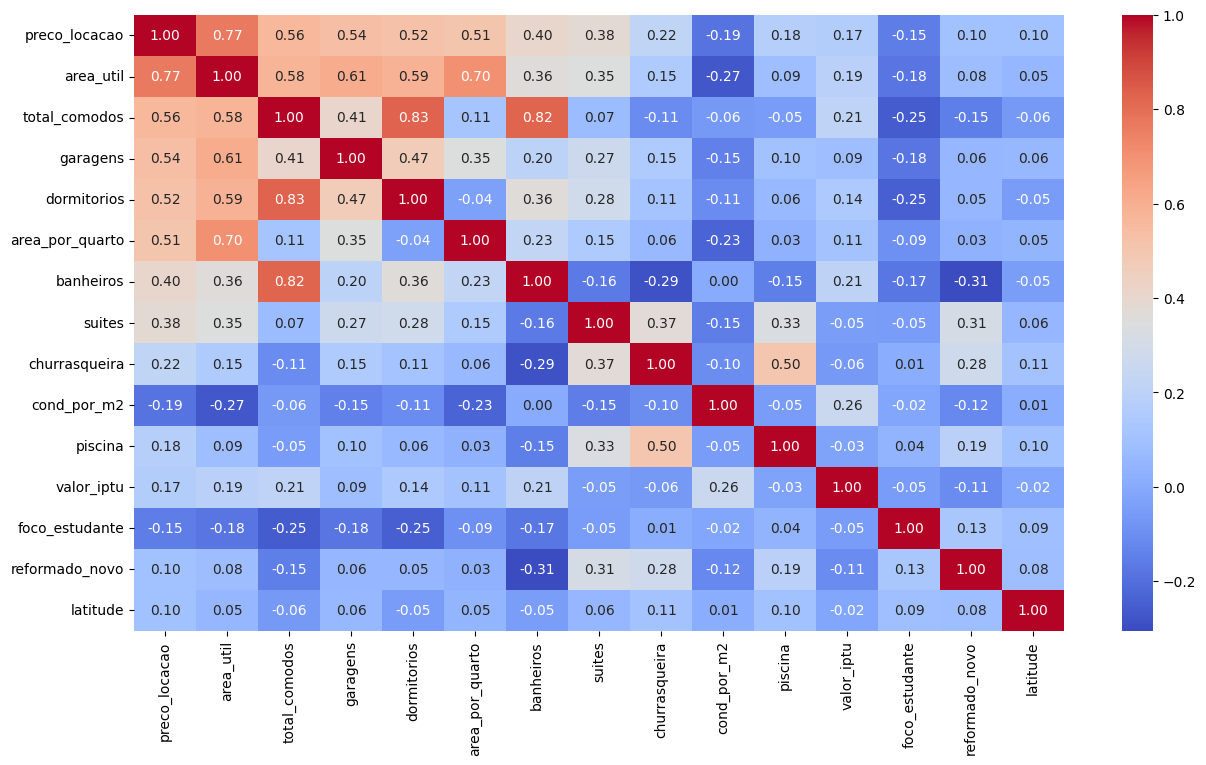

In [12]:
# Calcula a correlação de todas as numéricas
correlacao = df.corr(numeric_only=True)

# Pega as 10 colunas com maior correlação com 'preco_locacao' 
# (pegando os valores absolutos para considerar correlações negativas fortes também)
top_colunas = correlacao['preco_locacao'].abs().nlargest(15).index

# Aumenta o tamanho da figura
plt.figure(figsize=(15, 8))

# Plota o heatmap APENAS dessas 10 colunas
sns.heatmap(df[top_colunas].corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [13]:
df.iloc[0]

fonte                          cardinali
titulo              Apartamento - Padrão
tipo                         apartamento
subtipo                           padrao
finalidade                       locacao
preco_locacao                     1334.0
preco_venda                          NaN
valor_condominio                   195.0
valor_iptu                         129.0
bairro                            centro
dormitorios                            1
suites                                 0
banheiros                              1
garagens                               0
area_util                           38.0
descricao                              -
latitude                      -22.022019
longitude                     -47.892932
foco_estudante                         0
reformado_novo                         0
mobiliado                              0
piscina                                0
churrasqueira                          0
cond_por_m2                     5.131579
total_comodos   

In [12]:
features_limpas = [
    'tipo', 'area_util', 'bairro', 'area_por_quarto', 'dist_centro', 
    'dist_ufscar', 'dist_usp', 'dist_rodoviaria', 'garagens', 
    'total_comodos', 'dormitorios', 'banheiros', 'suites', 'reformado_novo', 
    'foco_estudante', 
    'latitude', 'longitude'
]

X = df[features_limpas].copy()
y = df['preco_locacao'].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ('bairro_enc', TargetEncoder(random_state=42), ['bairro']),
        ('tipo_enc', TargetEncoder(random_state=42), ['tipo']),
    ],
    remainder='passthrough'
)

In [13]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(
            n_estimators=300, 
            learning_rate=0.05, 
            max_depth=7, 
            num_leaves=31, 
            random_state=42, 
            n_jobs=-1,
            objective='mae',
            verbose=-1
        ),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res = cross_validate(pipe, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"LightGBM - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 534.03
MAE Folds: [490.59 473.31 624.48 518.15 563.61]
------------------------------------------------------------
R² Médio:  0.683
R² Folds:  [0.713 0.783 0.577 0.727 0.617]


/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [14]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'objective': 'mae',
        'verbose': -1,
    }

    pipe_opt = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=LGBMRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_validate(pipe_opt, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("="*60)
print("Melhores hiperparâmetros encontrados:")
print("-" * 60)
for k, v in study.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study.best_value:.2f}")
print("="*60)

  0%|          | 0/50 [00:00<?, ?it/s]/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning:

Melhores hiperparâmetros encontrados:
------------------------------------------------------------
  n_estimators          : 1410
  learning_rate         : 0.026486972818550458
  max_depth             : 8
  num_leaves            : 57
  min_child_samples     : 13
  subsample             : 0.6158577403716805
  colsample_bytree      : 0.8524814052733385
  reg_alpha             : 0.030048576042712678
  reg_lambda            : 0.056972935975453914

Melhor MAE: R$ 514.10


In [17]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'random_state': 42,
        'n_jobs': -1,
    }

    pipe_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=RandomForestRegressor(**params),
            func=np.log1p, inverse_func=np.expm1
        ))
    ])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(pipe_rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
    return -scores['test_score'].mean()

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=200, show_progress_bar=True)

print("="*60)
print("Random Forest - Melhores hiperparâmetros:")
print("-" * 60)
for k, v in study_rf.best_params.items():
    print(f"  {k:22s}: {v}")
print(f"\nMelhor MAE: R$ {study_rf.best_value:.2f}")
print("="*60)

Best trial: 139. Best value: 528.777: 100%|██████████| 200/200 [08:18<00:00,  2.49s/it]

Random Forest - Melhores hiperparâmetros:
------------------------------------------------------------
  n_estimators          : 956
  max_depth             : 18
  min_samples_split     : 3
  min_samples_leaf      : 1
  max_features          : 0.3387564855986707

Melhor MAE: R$ 528.78


In [18]:
best_rf = study_rf.best_params
best_rf.update({'random_state': 42, 'n_jobs': -1})

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=RandomForestRegressor(**best_rf),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_rf = cross_validate(pipe_rf, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_rf['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_rf['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_rf['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_rf['test_r2'], 3)}")
print("="*60)

Random Forest OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 528.78
MAE Folds: [507.63 510.59 553.98 554.87 516.81]
------------------------------------------------------------
R² Médio:  0.663
R² Folds:  [0.624 0.748 0.603 0.678 0.662]


In [15]:
best = study.best_params
best.update({'random_state': 42, 'n_jobs': -1, 'objective': 'mae', 'verbose': -1})

pipe_l = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(**best),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)
res_opt = cross_validate(pipe_l, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

pipe_l.fit(X, y)

print("="*60)
print(f"LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_opt['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_opt['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_opt['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_opt['test_r2'], 3)}")
print("="*60)

/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, 

LightGBM OTIMIZADO - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 514.10
MAE Folds: [437.66 511.43 492.72 444.15 529.69 601.56 477.11 521.51 555.66 569.48]
------------------------------------------------------------
R² Médio:  0.703
R² Folds:  [0.78  0.687 0.752 0.794 0.625 0.651 0.702 0.771 0.7   0.568]


In [ ]:
pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', TransformedTargetRegressor(
        regressor=KNeighborsRegressor(n_neighbors=7, weights='distance', n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_knn = cross_validate(pipe_knn, X, y, cv=kf, scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'})

print("="*60)
print(f"KNN - ALVO: ALUGUEL (preco_locacao)")
print("-" * 60)
print(f"MAE Médio: R$ {-res_knn['test_mae'].mean():.2f}")
print(f"MAE Folds: {-np.round(res_knn['test_mae'], 2)}")
print("-" * 60)
print(f"R² Médio:  {res_knn['test_r2'].mean():.3f}")
print(f"R² Folds:  {np.round(res_knn['test_r2'], 3)}")
print("="*60)

KNN - ALVO: ALUGUEL (preco_locacao)
------------------------------------------------------------
MAE Médio: R$ 592.03
MAE Folds: [587.39 568.9  651.89 577.52 574.46]
------------------------------------------------------------
R² Médio:  0.620
R² Folds:  [0.619 0.648 0.549 0.672 0.611]


In [ ]:
pipe_l.fit(X, y)
feat_names = ['bairro_encoded', 'tipo_encoded'] + [c for c in X.columns if c not in ['bairro', 'tipo']]
importances = pipe_l.named_steps['regressor'].regressor_.feature_importances_
importances = importances / importances.sum()

print("\n=== Peso das Features no Preço (LightGBM) ===")
for n, i in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    if i > 0.001:
        bar = '█' * int(i * 100)
        print(f"  {n:22s}: {i:.4f} {bar}")


=== Peso das Features no Preço (LightGBM) ===
  area_util             : 0.1260 ████████████
  bairro_encoded        : 0.1231 ████████████
  area_por_quarto       : 0.1141 ███████████
  dist_centro           : 0.0826 ████████
  longitude             : 0.0815 ████████
  dist_ufscar           : 0.0790 ███████
  dist_usp              : 0.0757 ███████
  latitude              : 0.0730 ███████
  tipo_encoded          : 0.0707 ███████
  dist_rodoviaria       : 0.0597 █████
  total_comodos         : 0.0280 ██
  garagens              : 0.0280 ██
  banheiros             : 0.0201 ██
  suites                : 0.0177 █
  dormitorios           : 0.0110 █
  reformado_novo        : 0.0072 
  foco_estudante        : 0.0025 


In [ ]:
import joblib
from pathlib import Path

model_dir = Path('../models')
model_dir.mkdir(exist_ok=True)
joblib.dump(pipe_l, model_dir / 'modelo_aluguel.pkl')
print("Modelo salvo em ../models/modelo_aluguel.pkl")

Modelo salvo em ../models/modelo_aluguel.pkl


In [ ]:
KM_DEGREE = 111
CENTRO_LAT, CENTRO_LON = -22.0174, -47.8908
UFSCAR_LAT, UFSCAR_LON = -21.9839, -47.8822
USP_CAMPUS1_LAT, USP_CAMPUS1_LON = -22.0063, -47.8946
RODOVIARIA_LAT, RODOVIARIA_LON = -22.0304, -47.8823

EMBARE_LAT, EMBARE_LON = -21.9960, -47.8560
VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON = -22.0135, -47.8960

def calc_dist(lat, lon, ref_lat, ref_lon):
    return np.sqrt((lat - ref_lat)**2 + (lon - ref_lon)**2) * KM_DEGREE

imoveis = pd.DataFrame([
    {
        'nome': 'Jardim Embaré - 2q, 1ban, 54m²',
        'tipo': 'apartamento',
        'area_util': 54, 'bairro': 'jardim embare', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 1, 'suites': 0,
        'reformado_novo': 0, 'foco_estudante': 0,
        'total_comodos': 3, 'area_por_quarto': 27,
        'latitude': EMBARE_LAT, 'longitude': EMBARE_LON,
        'dist_centro': calc_dist(EMBARE_LAT, EMBARE_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(EMBARE_LAT, EMBARE_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(EMBARE_LAT, EMBARE_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(EMBARE_LAT, EMBARE_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Centro - 2q, 1ban, 50m²',
        'tipo': 'apartamento',
        'area_util': 50, 'bairro': 'centro', 'dormitorios': 2, 'banheiros': 1,
        'garagens': 0, 'suites': 0,
        'reformado_novo': 1, 'foco_estudante': 0,
        'total_comodos': 3, 'area_por_quarto': 25,
        'latitude': CENTRO_LAT, 'longitude': CENTRO_LON,
        'dist_centro': 0,
        'dist_ufscar': calc_dist(CENTRO_LAT, CENTRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(CENTRO_LAT, CENTRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(CENTRO_LAT, CENTRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
    {
        'nome': 'Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)',
        'tipo': 'apartamento',
        'area_util': 95, 'bairro': 'vila monteiro', 'dormitorios': 3, 'banheiros': 2,
        'garagens': 2, 'suites': 1,
        'reformado_novo': 0, 'foco_estudante': 0,
        'total_comodos': 5, 'area_por_quarto': 95/3,
        'latitude': VILA_MONTEIRO_LAT, 'longitude': VILA_MONTEIRO_LON,
        'dist_centro': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, CENTRO_LAT, CENTRO_LON),
        'dist_ufscar': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, UFSCAR_LAT, UFSCAR_LON),
        'dist_usp': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, USP_CAMPUS1_LAT, USP_CAMPUS1_LON),
        'dist_rodoviaria': calc_dist(VILA_MONTEIRO_LAT, VILA_MONTEIRO_LON, RODOVIARIA_LAT, RODOVIARIA_LON),
    },
])

precos = pipe_l.predict(imoveis[features_limpas])
for i, row in imoveis.iterrows():
    print(f"{row['nome']}")
    print(f"  Aluguel previsto: R$ {precos[i]:.2f}")

print(f"\nValor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)")
print(f"  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)")

Jardim Embaré - 2q, 1ban, 54m²
  Aluguel previsto: R$ 1295.10
Centro - 2q, 1ban, 50m²
  Aluguel previsto: R$ 1406.09
Vila Monteiro - 3q, 2ban, 95m² (Cardinali 238063)
  Aluguel previsto: R$ 2438.77

Valor real Vila Monteiro (Cardinali): R$ 2.000,00 (aluguel)
  Total no site: R$ 2.792,85 (aluguel + cond R$660 + IPTU R$132,85)


/Users/josemaiadeoliveira/am/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
